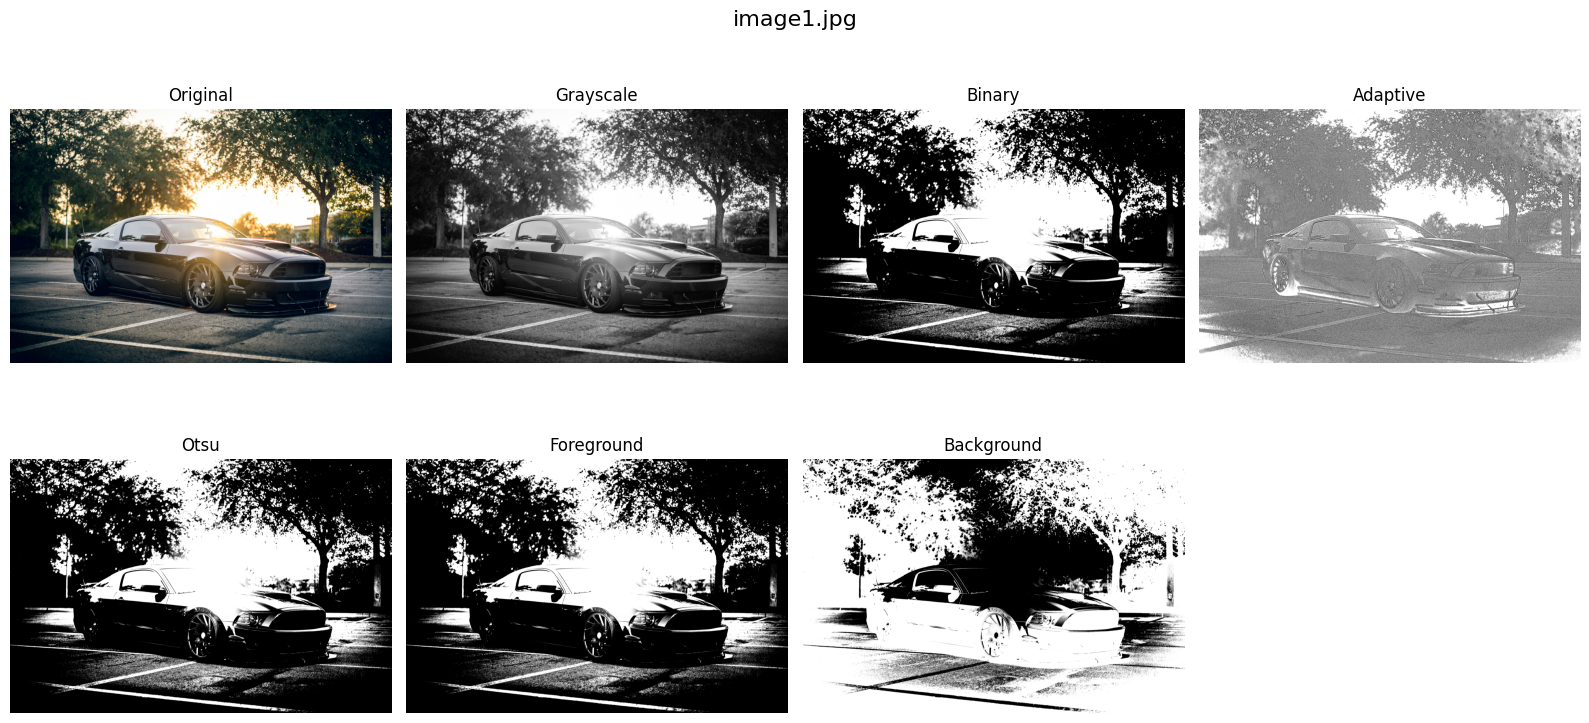

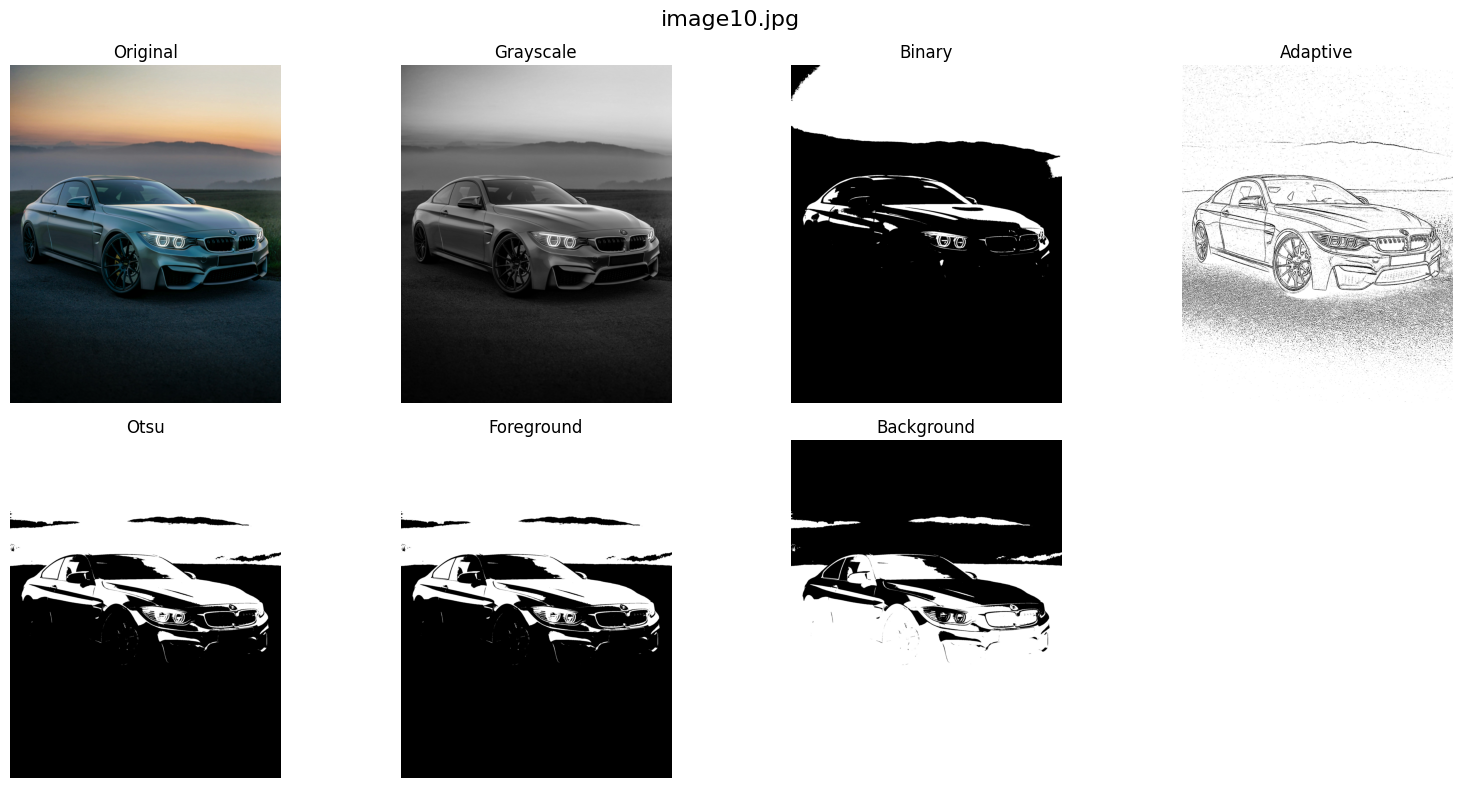

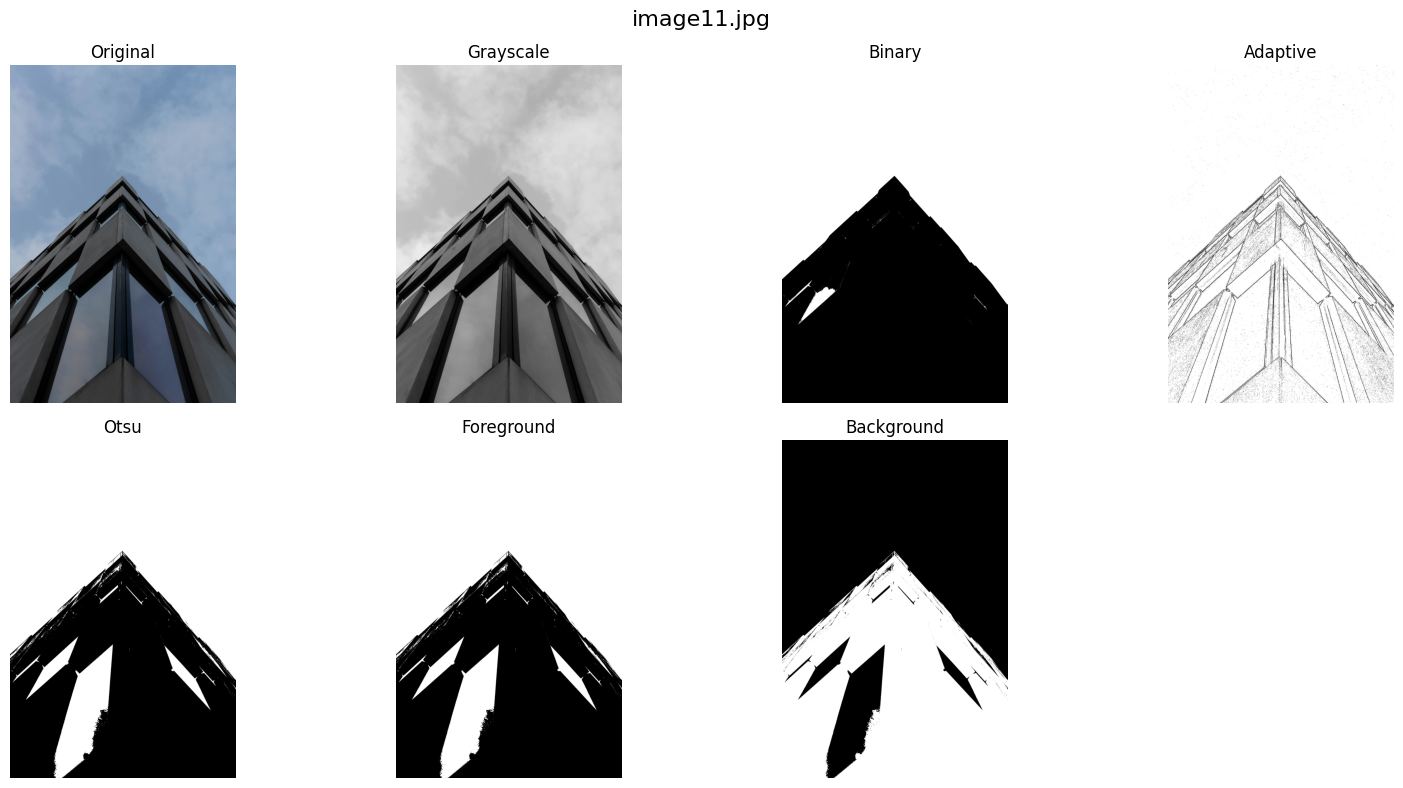

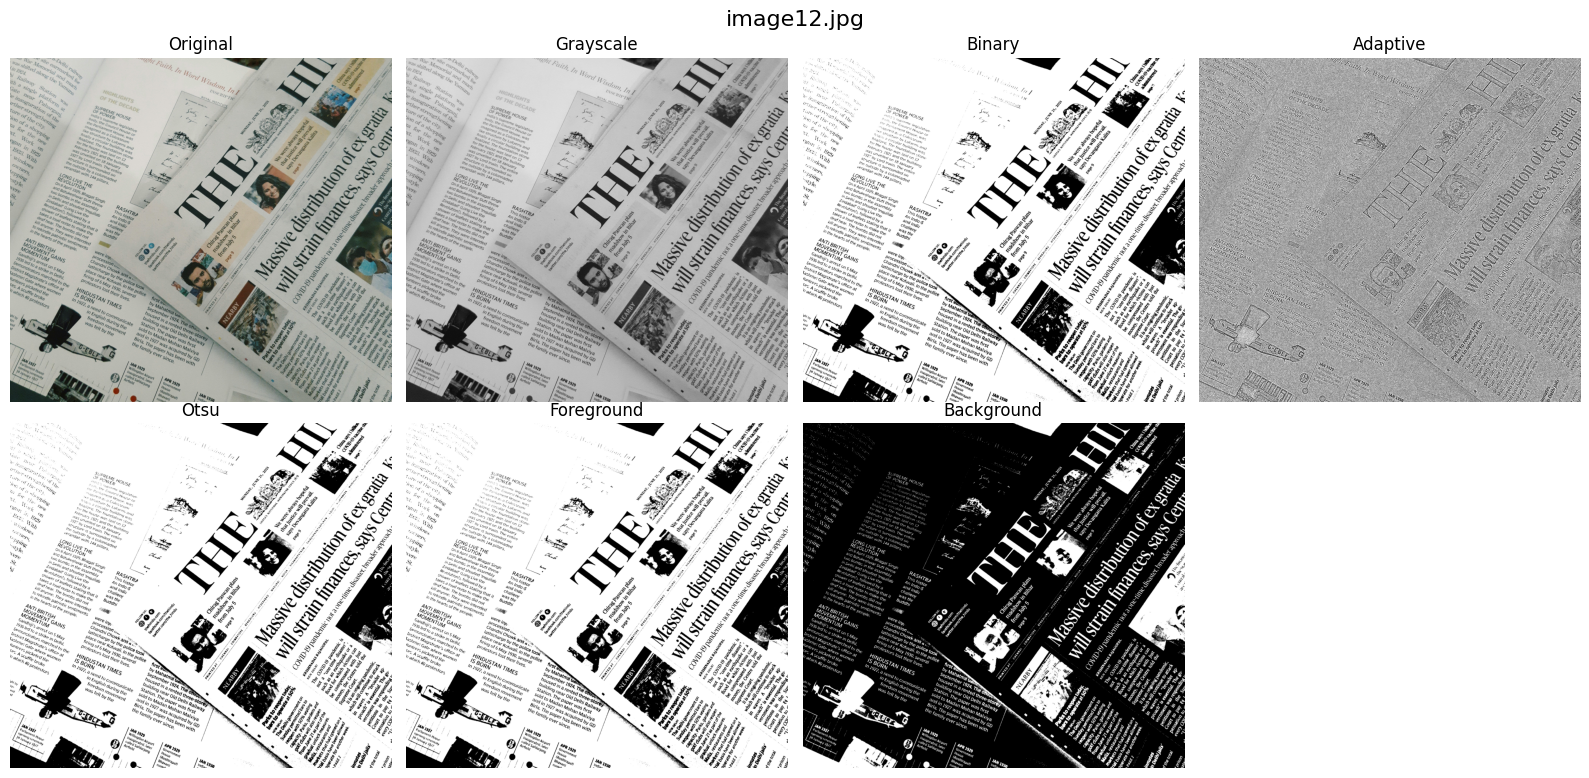

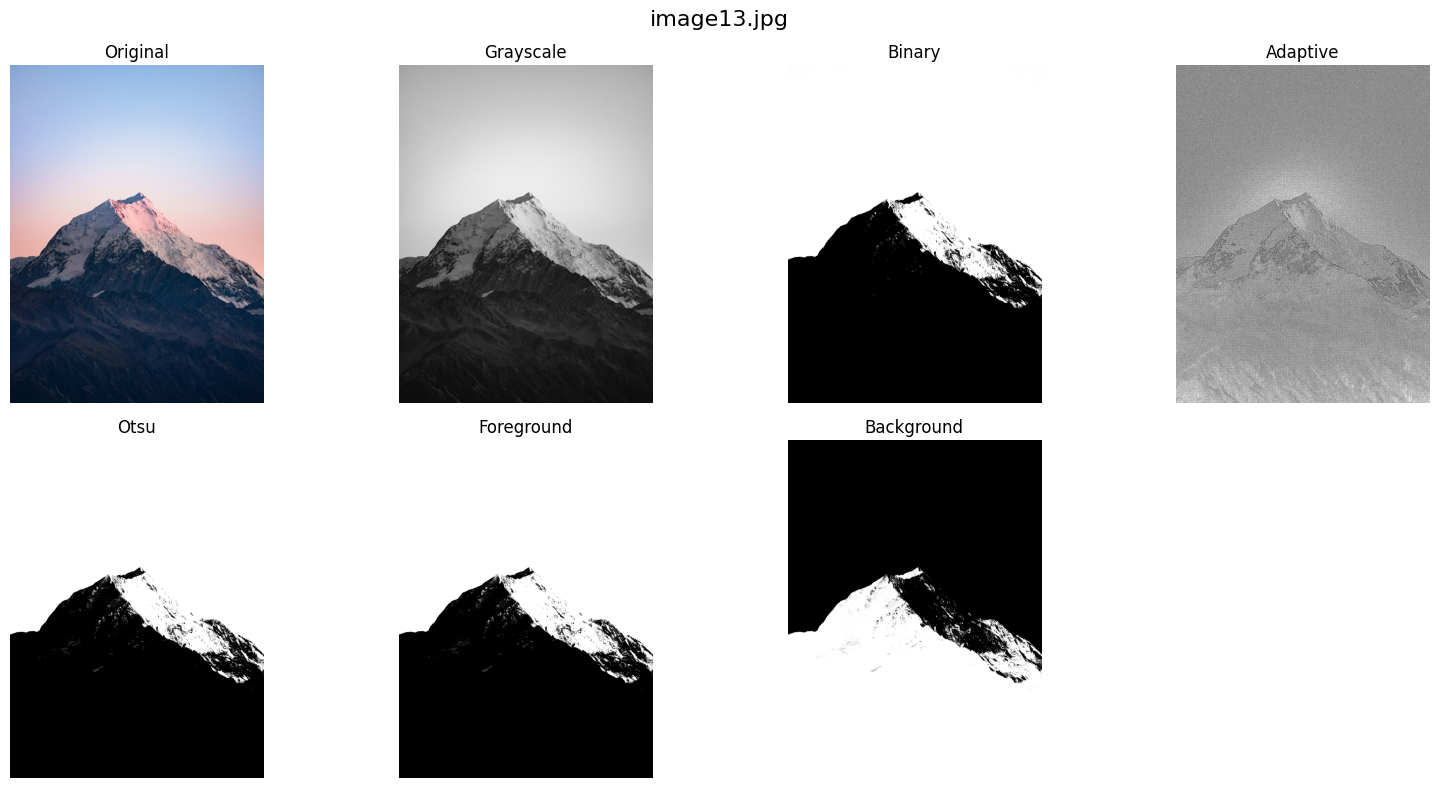

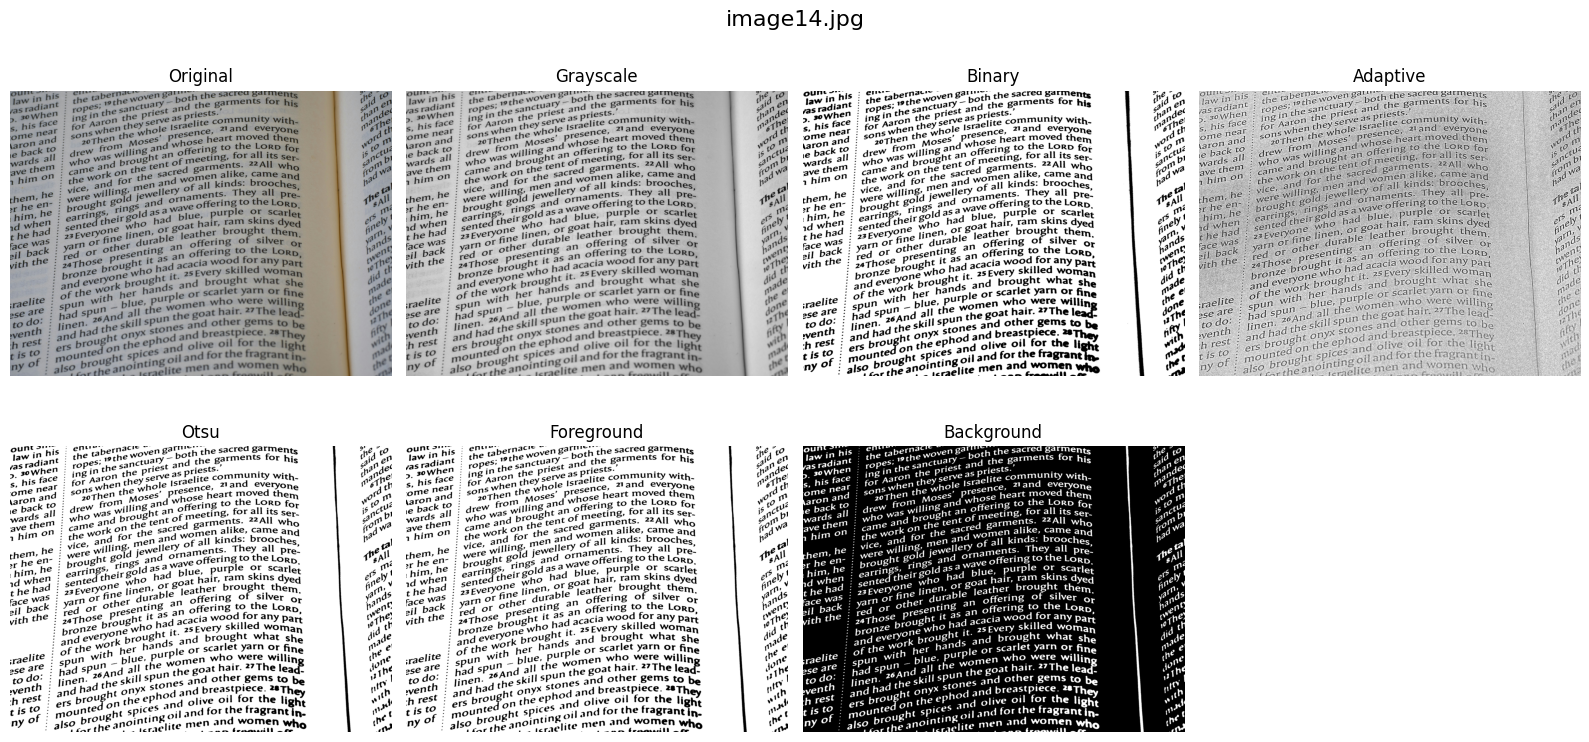

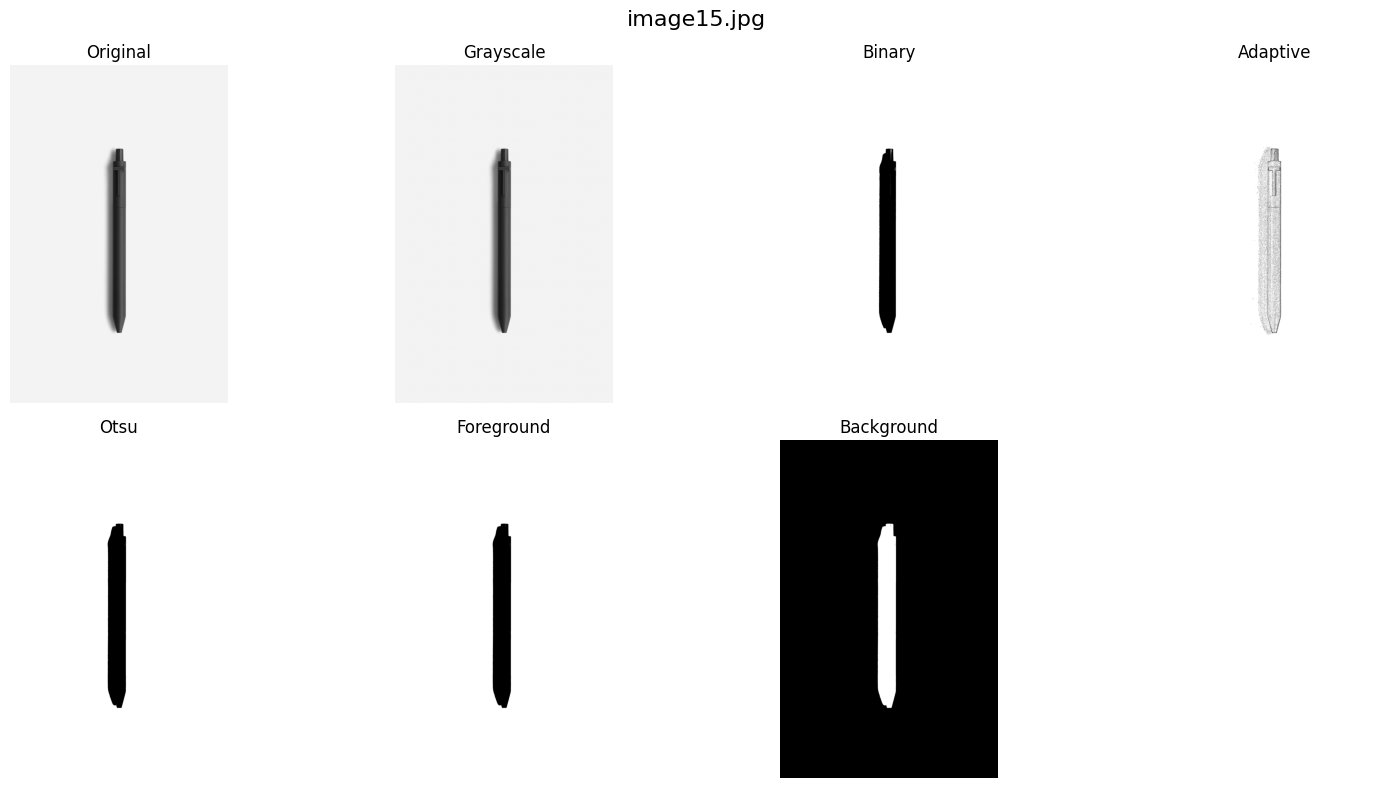

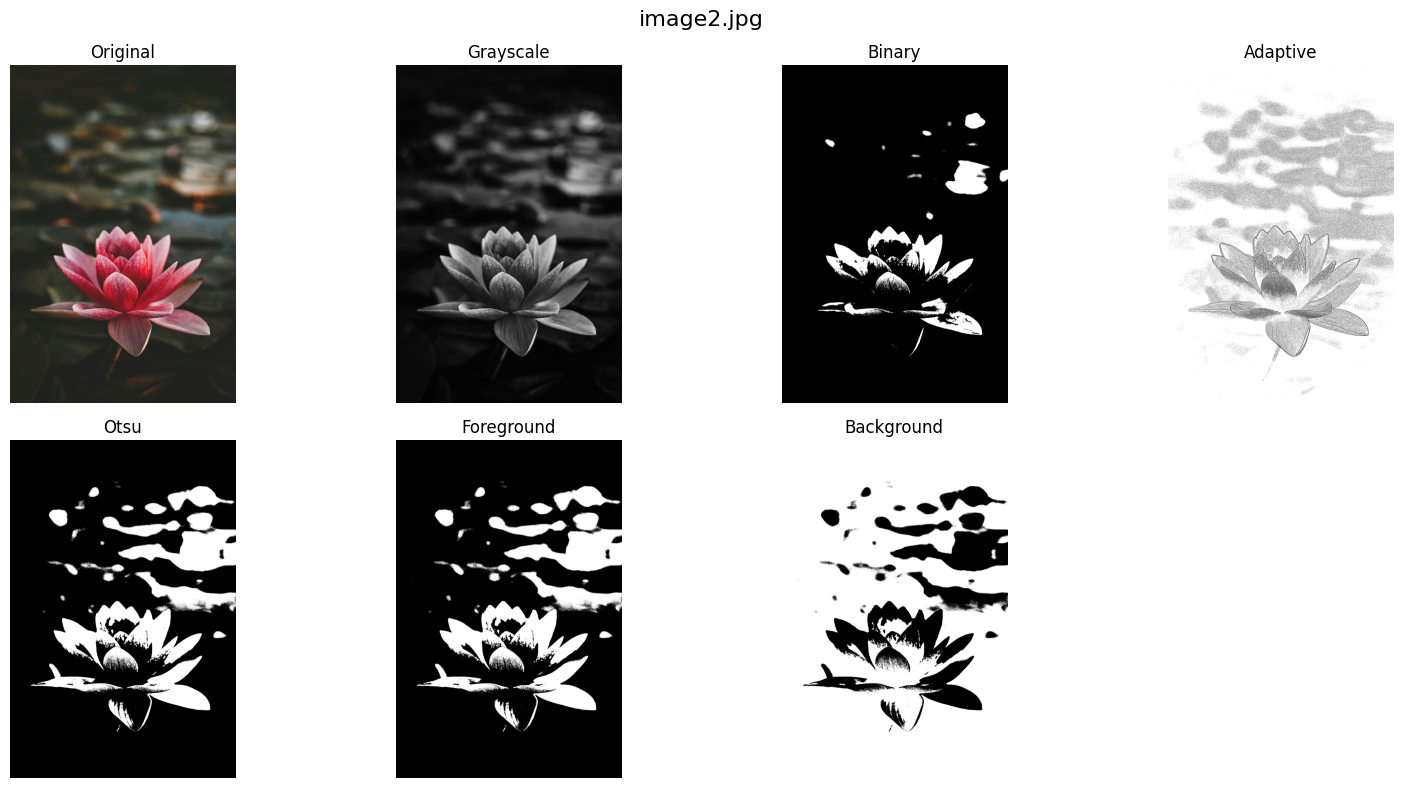

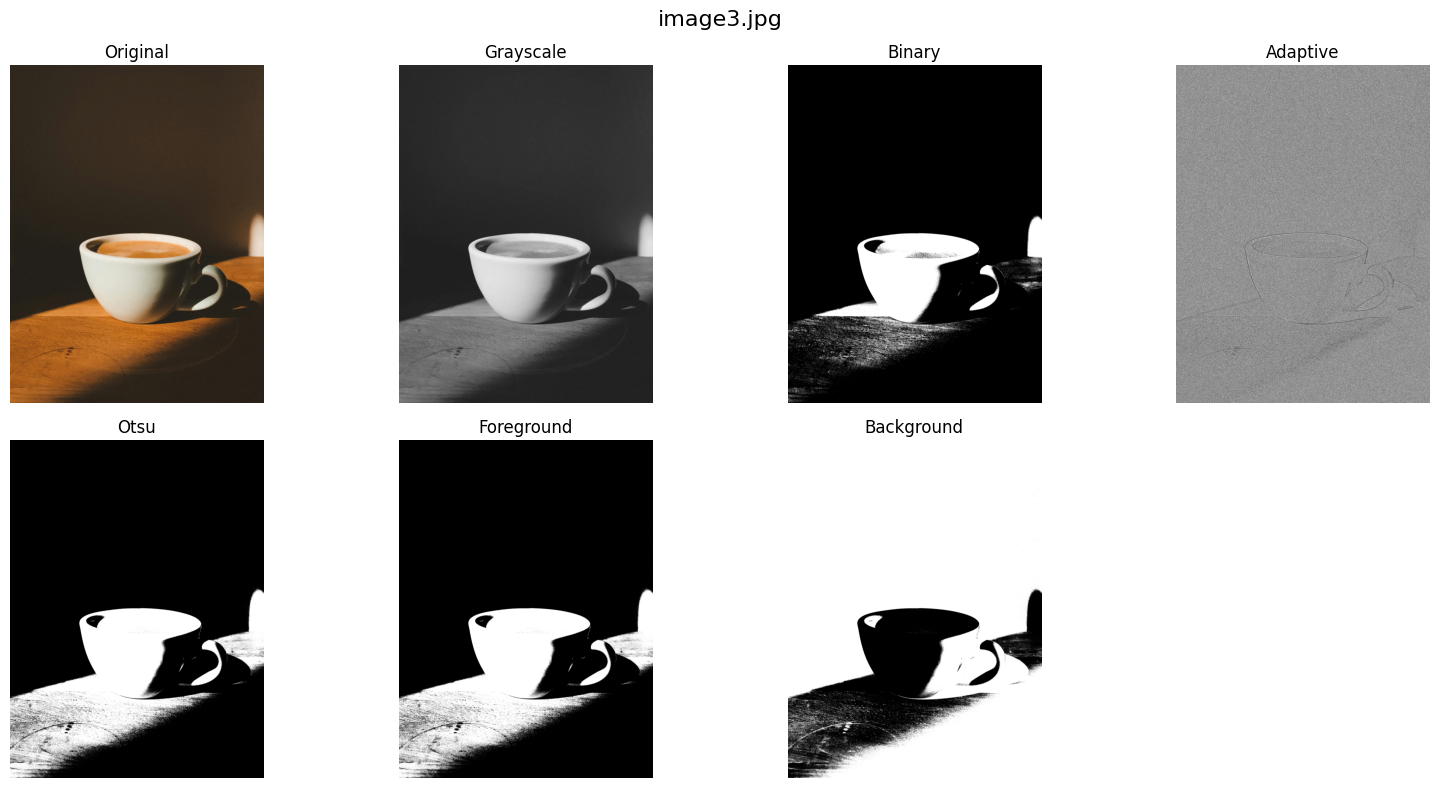

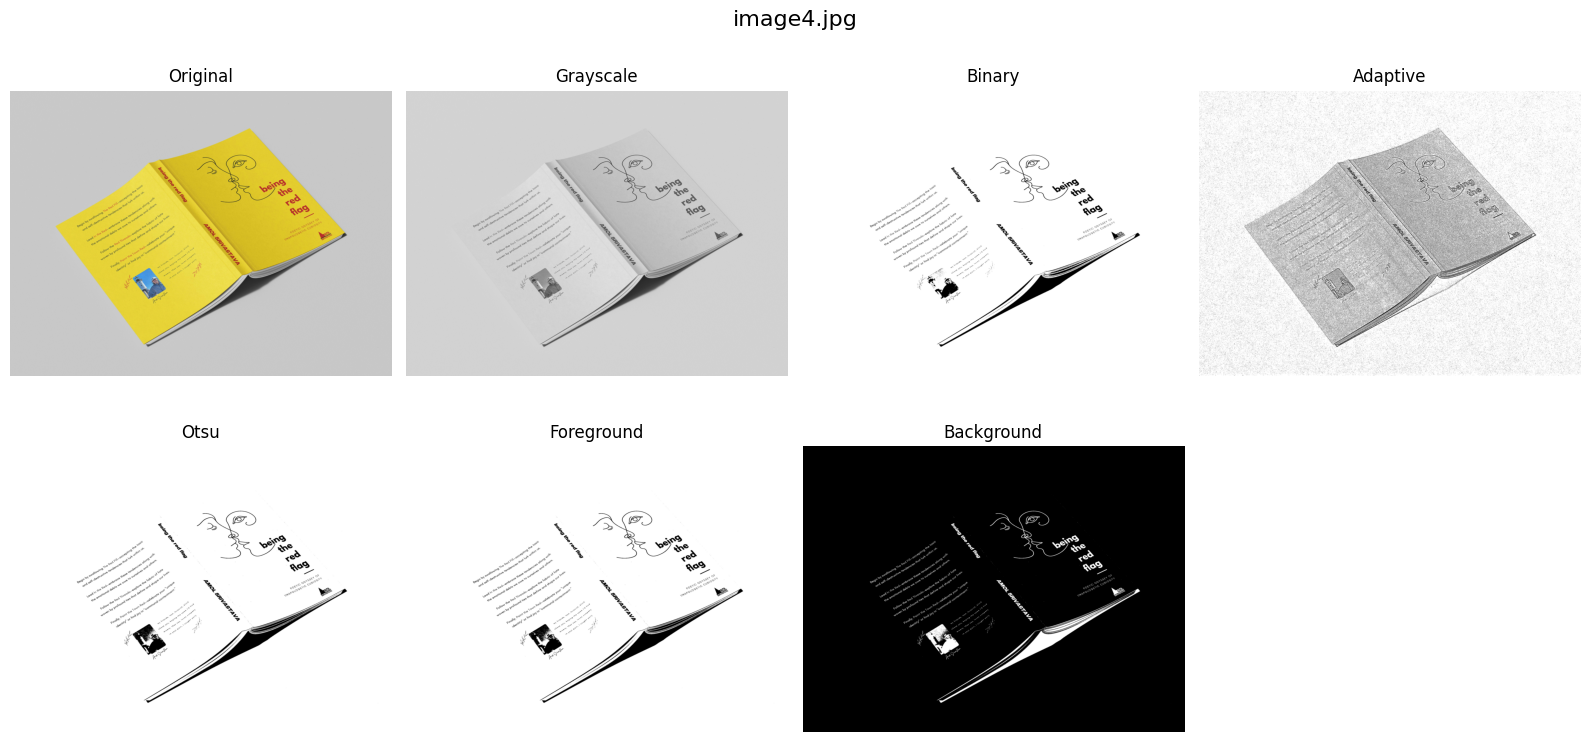

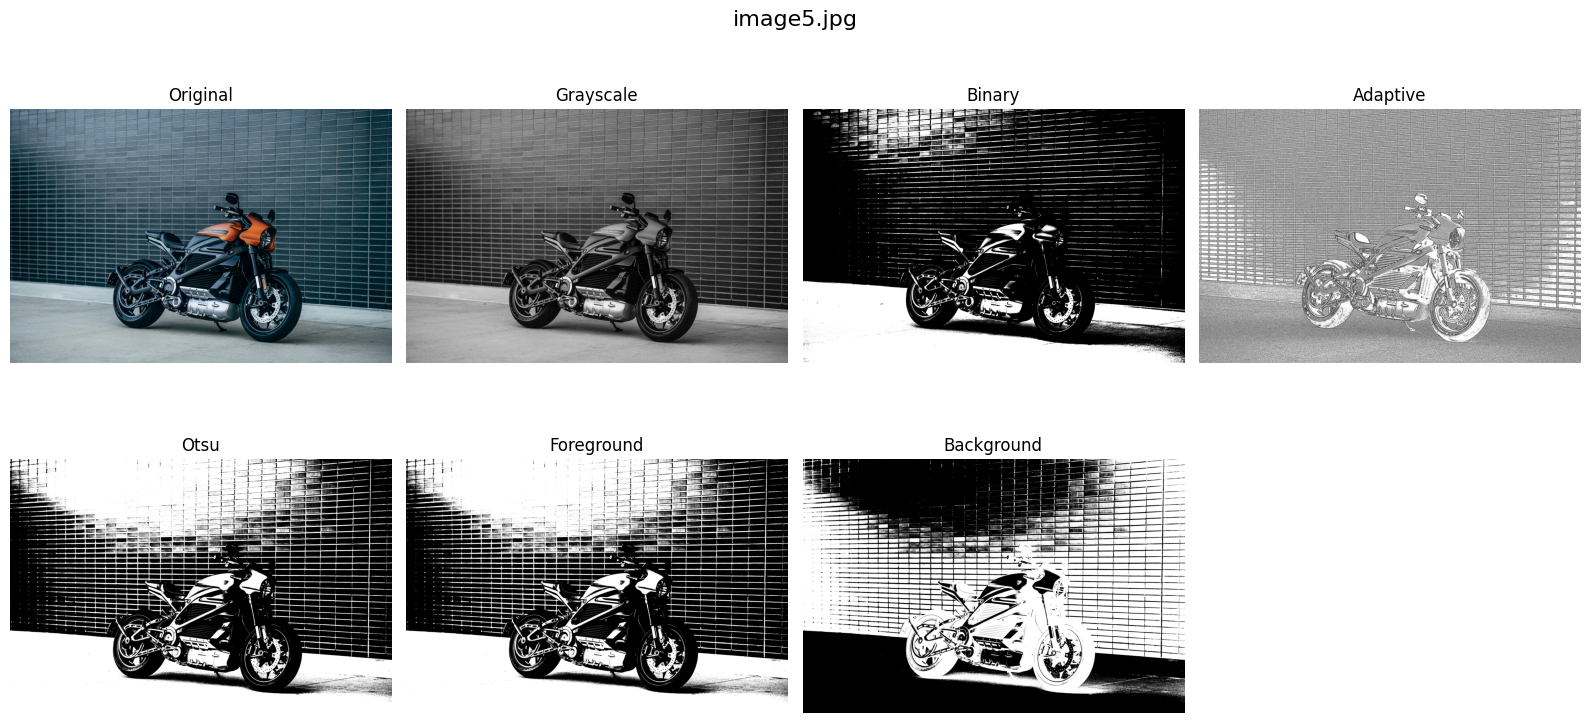

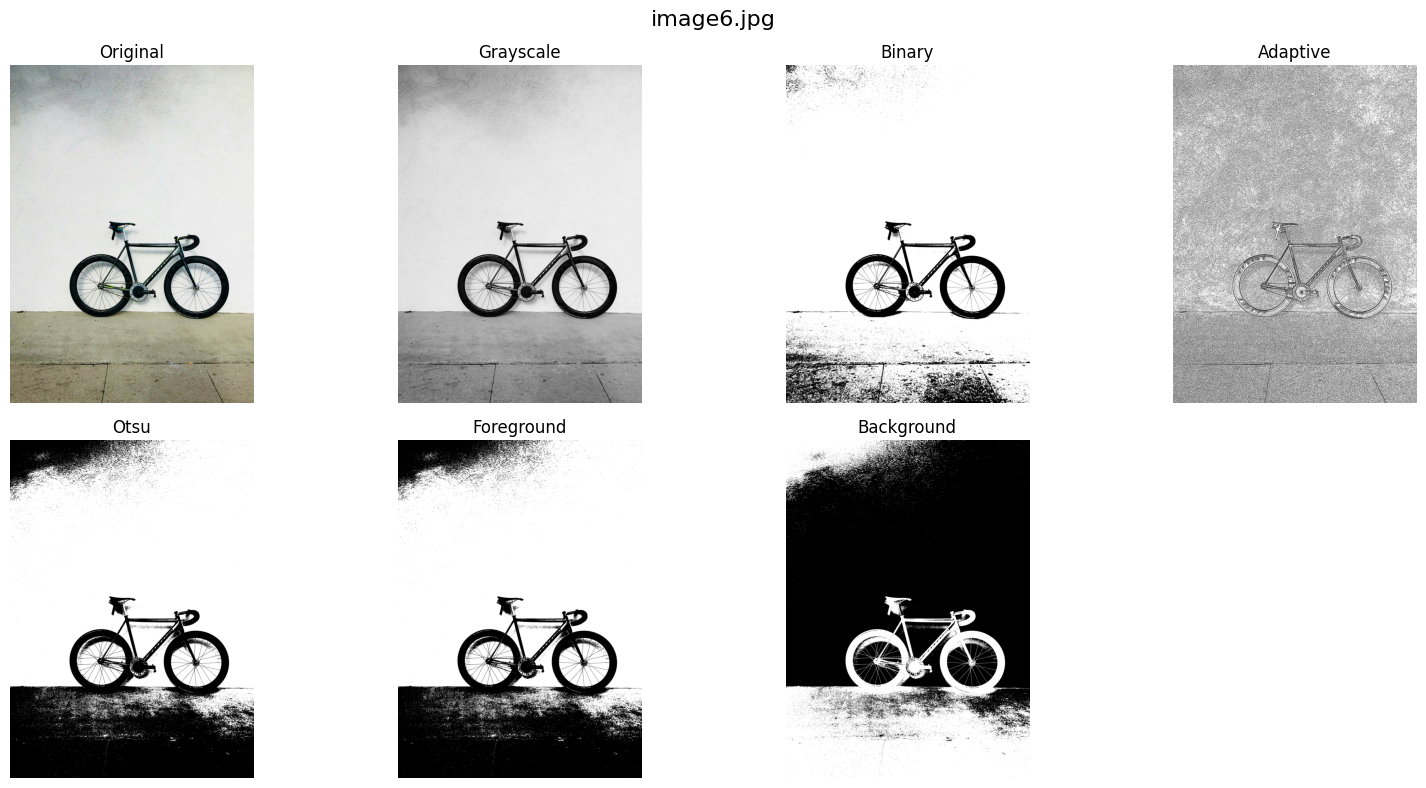

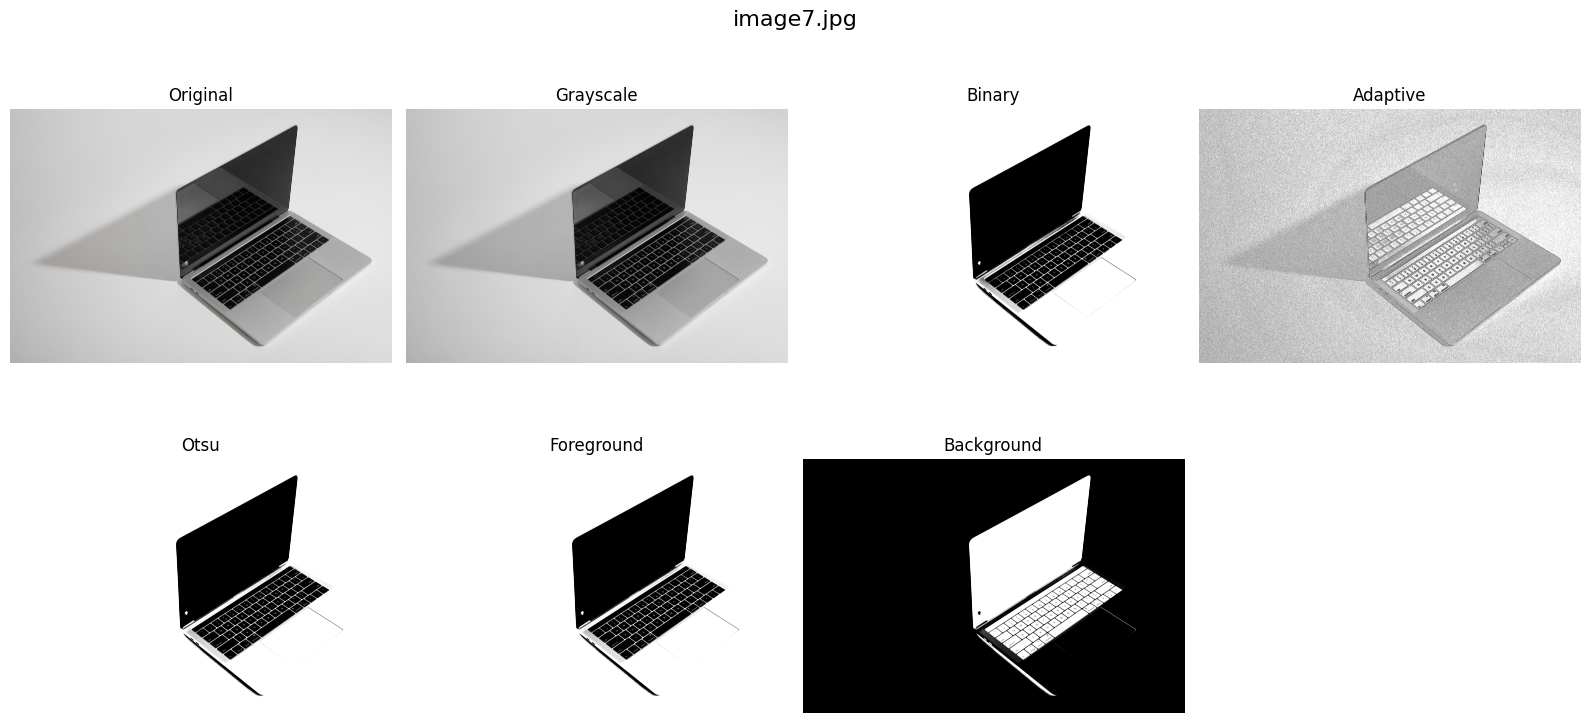

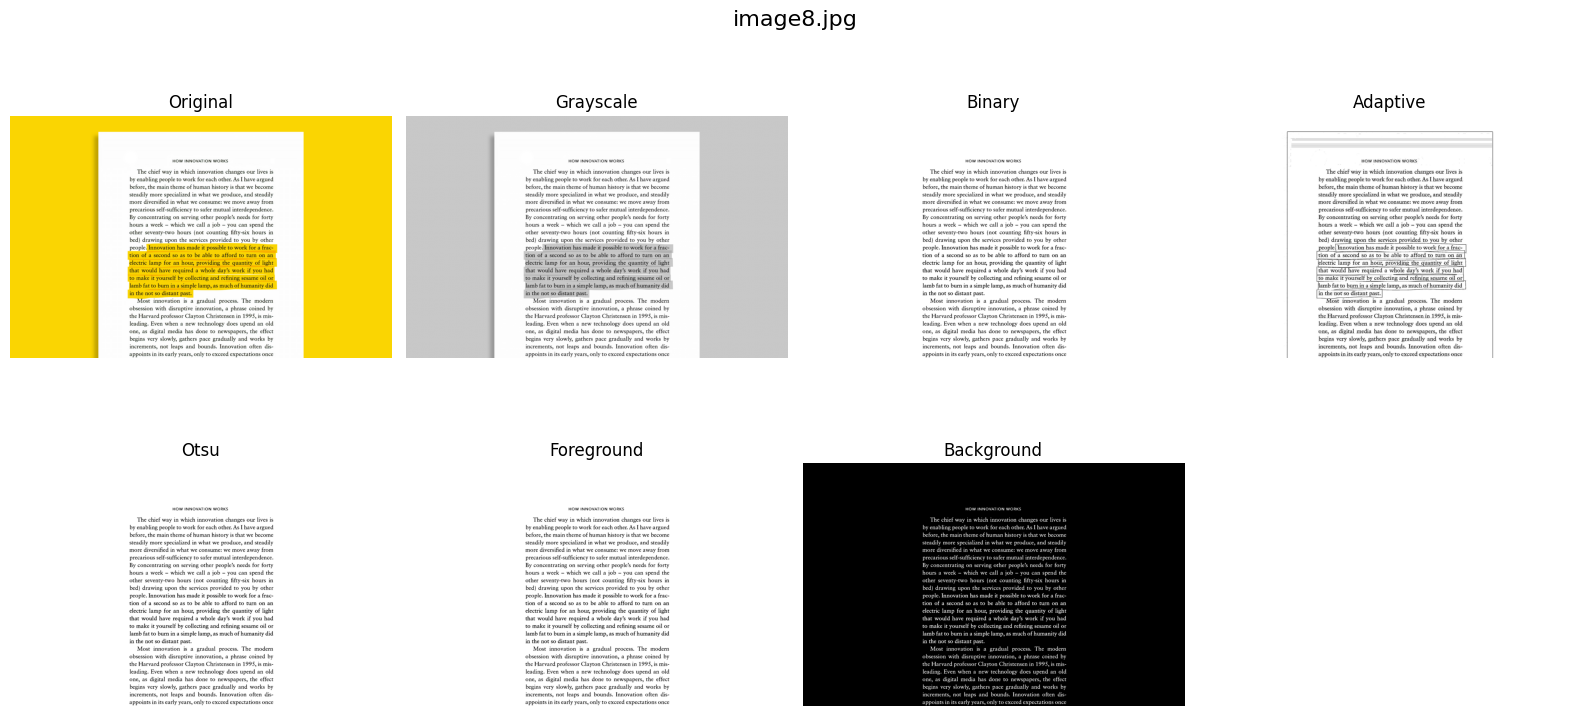

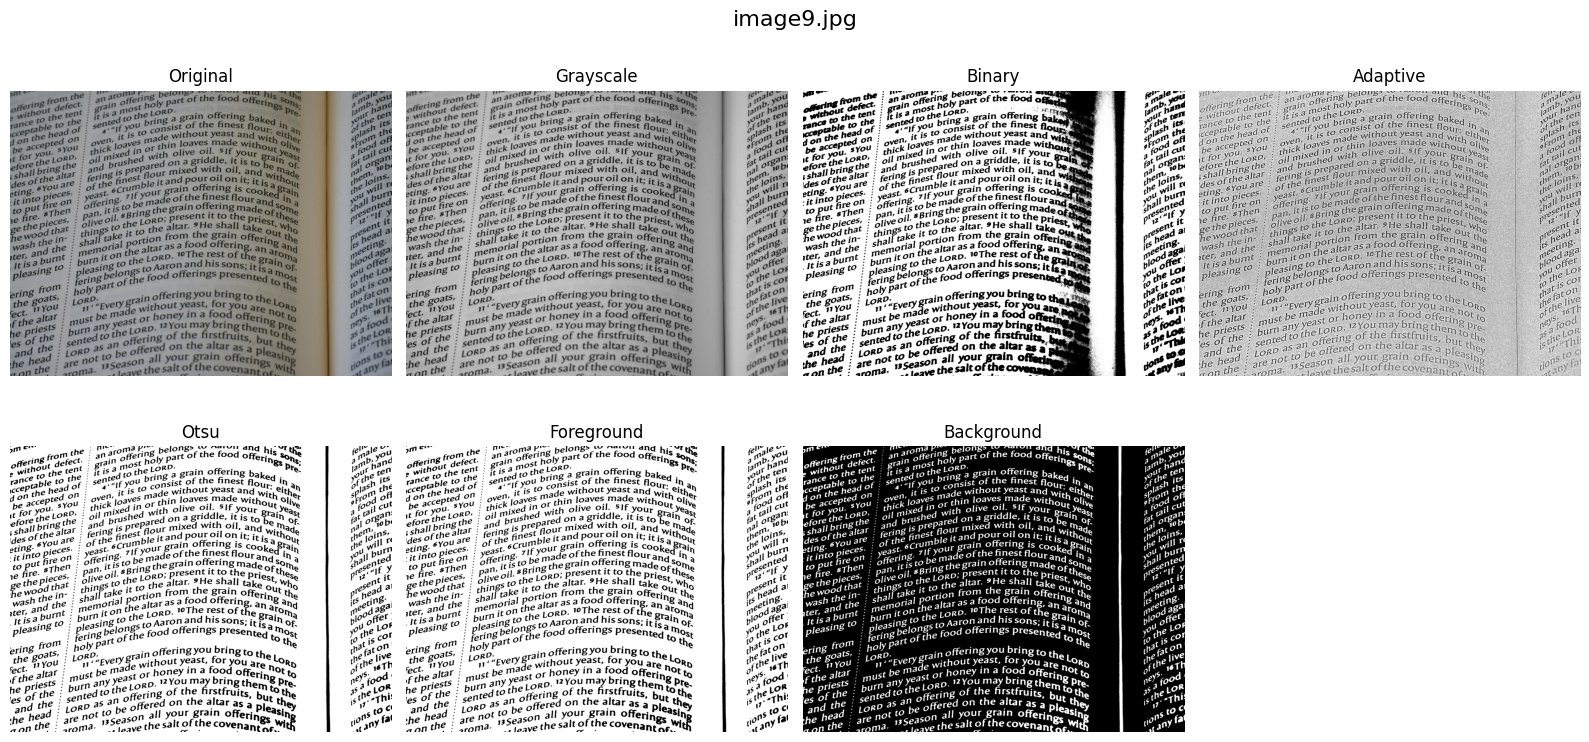

All images processed successfully.
Results saved inside the output folder.


In [2]:
import cv2
import matplotlib.pyplot as plt
import os

# Input and Output Folders
input_folder = "images"
output_folder = "output"

# Create output subfolders
binary_folder = os.path.join(output_folder, "binary")
adaptive_folder = os.path.join(output_folder, "adaptive")
otsu_folder = os.path.join(output_folder, "otsu")
foreground_folder = os.path.join(output_folder, "foreground")
background_folder = os.path.join(output_folder, "background")
best_folder = os.path.join(output_folder, "best_segmentation")

os.makedirs(binary_folder, exist_ok=True)
os.makedirs(adaptive_folder, exist_ok=True)
os.makedirs(otsu_folder, exist_ok=True)
os.makedirs(foreground_folder, exist_ok=True)
os.makedirs(background_folder, exist_ok=True)
os.makedirs(best_folder, exist_ok=True)

# Supported Image Formats
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")


# Process Every Image

for filename in os.listdir(input_folder):

    if not filename.lower().endswith(image_extensions):
        continue

    image_path = os.path.join(input_folder, filename)

    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not read {filename}")
        continue

    # Convert to Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Binary Thresholding
    _, binary = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Adaptive Thresholding
    adaptive = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # Otsu Thresholding
    _, otsu = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Foreground
    foreground = otsu

    # Background
    background = cv2.bitwise_not(foreground)

    # Display Results
    titles = [
        "Original",
        "Grayscale",
        "Binary",
        "Adaptive",
        "Otsu",
        "Foreground",
        "Background"
    ]

    images = [
        cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
        gray,
        binary,
        adaptive,
        otsu,
        foreground,
        background
    ]

    plt.figure(figsize=(16,8))

    for i in range(len(images)):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(filename, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Save Results
    cv2.imwrite(os.path.join(binary_folder, filename), binary)
    cv2.imwrite(os.path.join(adaptive_folder, filename), adaptive)
    cv2.imwrite(os.path.join(otsu_folder, filename), otsu)
    cv2.imwrite(os.path.join(foreground_folder, filename), foreground)
    cv2.imwrite(os.path.join(background_folder, filename), background)

    # Save Best Segmentation
    cv2.imwrite(os.path.join(best_folder, filename), otsu)

print("All images processed successfully.")
print("Results saved inside the output folder.")